## Preperations

### Setup Conda Environment and Jupyter Kernel

**First time setup (run in terminal):**
```bash
# Create the environment
conda create -n af -y -c bioconda simpleaf

# Activate it
conda activate af

# Install ipykernel so Jupyter can see this environment
conda install -y ipykernel

# Register it as a Jupyter kernel
python -m ipykernel install --user --name af --display-name "Python (af)"
```

**After setup:**
1. In VS Code, click the kernel selector (top right of this notebook)
2. Select "Python (af)" from the list
3. If it doesn't appear, reload VS Code window (Cmd+Shift+P → "Reload Window")

---

#### Original bash tutorial commands (for reference):
```bash
wget -qO- https://umd.box.com/shared/static/lx2xownlrhz3us8496tyu9c4dgade814.gz | tar xzf - --strip-components=1 -C .
fastq_dir="toy_read_fastq"
ref_dir="toy_human_ref"

wget -qO- https://raw.githubusercontent.com/10XGenomics/cellranger/master/lib/python/cellranger/barcodes/3M-february-2018.txt.gz | gunzip - > 3M-february-2018.txt
```

## Download and Prepare Toy Dataset

Download the toy scRNA-seq dataset (FASTQ reads and reference genome) and the 10X Genomics barcode whitelist. This small dataset allows for quick testing of the simpleaf pipeline.

In [ ]:
# Import Dependencies
import urllib.request
import tarfile
import gzip
import shutil
import os
import subprocess
import glob

#### Finding the Correct URL to Download Toy Dataset
Getting the correct url was a bit of a hassle. I ended up having to use chromes devtools to find the http request sent when the "download" button is pressed on app.box.com to download the dataset. Thats why my dataset_url is so long.

UPDATE1: The download url I was using is actually a temporary signed link that changes every time the Download button is clicked, because of this I may have to simply include the Toy Dataset in the repo.

UPDATE2: The toy reference dataset is too large to push to github, I will be using a condensed version for the CI.

In [2]:
# Using Download URL to fetch Toy Dataset (Currently Broken)
'''

# Set working directory
work_dir = "af_xmpl_run"
os.makedirs(work_dir, exist_ok=True)
os.chdir(work_dir)

print("=== Downloading toy dataset ===")
# Download toy dataset
dataset_url = "https://public.boxcloud.com/d/1/b1!eEAwiS_uVkn8FDW53cMxWB8Gc1JM0UtQjFkSLzrMmk2tk7xGx0rUctQxx9d19Z9NHeyTJomz-fWC7mcsW5myFwDrY9q_zg-HPLVXY1IdNXIX_Vh0RL3ZPvmeZQntT-0AdQV0sq1IWJFmckhpRDbdyp6jQ8M3mIxdfKEhv2ArRjqA7MGEI5F96FloAQHi6kmUrRbKb0MnTOYU8jFn4X1Yh4DkrdpNGgAYlgxhS12Dh7V2DEf1QeqyNnwwPfQJS0UxHZRNslSl1cxyV2tBIHUYe0lMZfOjgxQg20tJyR4zT_WfV21QMwZSYZ4I7bjDkOL_mHJC5sFfAmrwYMa2aFJHO0JiQIxcB1na-Gau1BO8s5patLffWfZQFOVPmqAcrJEgMpfJRjnYQgXbwt7vIUKcgwFV6bj-oI8J68BQDGfRqumpQCPiDypXU5ft0OdVHD-vLSHSE6brWsMxvT5BWZwqSKpQ6C4N_ISddcAQPTJbHe652UROS7X8cwcSKlMaNp8lRtC4PxhpMYyO8RD5PiN_FaOktlBoyl7BZRoDcbUeQ72poAkTjHvdYHHTGu04YdD3J9mai17Ql1AjnwWvsQeDcqBf7bsppY6O7O8eo8PCqBRWi-yfjKAB-h2nBpxts-DXl-w62gReRagWwK_LBc5ammKeTS8bVKB975LVs7S4VSviicIpbE0x6khaSvNf-2ZDqNTRljwhzFc-jUt5ev6z3FlcbSE70-pVhFM88R7kmKOMiMLz3_XzYgjDmkpvTSfJ5_QZKtQ9MZ6e9VnSP4R3O7u-eRXIsmq_ueD-7vl93qvWG3FBiAjLuyBBlHPMnj_qsBB0SwrHiggm8LeV6rwGAhtZNhgJu0YJ1i3TlJ3donGWZau-fUhS8PiLkIXAy-30GtinIUWwVGEKNcNs0TMiqOf9R_kc6608qOevQRNLmTYimCP8OJqHArBUKSb4bSb4yzUjqav78nfich67nMUQkBFeGsQvAxjkjaUxCg0t5MtwdtQMp60ofwrHQrcdeauTcvhZBuqpj_WGAx69kYTmVXki2mQ-1wGjoUyxzdoRtLJ9f6E9WksezvhfPmULujjoWwjf_95bH4MPqZpRBUNkU-TFLN3uw149xeHRHKtyqM1Otx3nq9Etm04cIJGeRtWbsg_GXMDKZ0rA3H7batkB5qGJ6QqGUpDaMv_lXj_eUu_phXtFv2q_j6LJEiBeovRPHO7yweU9XpXmiRbkQFCucexBzAfgPVyqrB45eqn6bQ-z1yK0rfmb3uLjxmHhoFI0TRKa8LcXiYbjmNQXEIu8JvDm4hDHD6ieVrTNNVeymS_Z8lqOIDhGvvqYouspq-H6Hy2MlKViYDgElbnIfGcpV5LQeG_2y7-fl2wL97tjftWFmMqyAxVcDbtN2itc_Mt5irmxYp1poaLWt7SvYDnoR9s6tdq87BE_4fMkdutEQXK3i9x95EMW-Gis_DfNINrIHGE./download"
dataset_file = "dataset.tar.gz"

print(f"Downloading from {dataset_url}...")
urllib.request.urlretrieve(dataset_url, dataset_file)
print(f"✓ Downloaded {os.path.getsize(dataset_file)} bytes")

# Extract dataset
print("Extracting dataset...")
with tarfile.open(dataset_file, 'r:gz') as tar:
    tar.extractall()

os.remove(dataset_file)
print("✓ Dataset extracted")

# Set directory variables
fastq_dir = "toy_read_fastq"
ref_dir = "toy_human_ref"

print(f"✓ FASTQ directory: {fastq_dir}")
print(f"✓ Reference directory: {ref_dir}")

'''


# Getting Dataset from Local Copy
print("=== Locating toy dataset ===")

# Direct path to data - no copying needed
fastq_dir = 'data/sample-data/toy_ref_read/toy_read_fastq'
ref_dir = 'data/sample-data/toy_ref_read/toy_human_ref'

# Verify they exist
if not os.path.exists(fastq_dir):
    raise FileNotFoundError(f"FASTQ directory not found at {fastq_dir}")
if not os.path.exists(ref_dir):
    raise FileNotFoundError(f"Reference directory not found at {ref_dir}")

print(f"✓ FASTQ directory: {fastq_dir}")
print(f"✓ Reference directory: {ref_dir}")
print(f"✓ Dataset ready to use")

=== Locating toy dataset ===
✓ FASTQ directory: data/sample-data/toy_ref_read/toy_read_fastq
✓ Reference directory: data/sample-data/toy_ref_read/toy_human_ref
✓ Dataset ready to use


#### Downloading the Barcode WhiteList

In [3]:
# Download 10X barcode whitelist
print("\n=== Downloading 10X barcode whitelist ===")
barcode_url = "https://github.com/f0t1h/3M-february-2018/raw/refs/heads/master/3M-february-2018.txt.gz"
barcode_gz = "3M-february-2018.txt.gz"
barcode_txt = "3M-february-2018.txt"

print(f"Downloading barcode whitelist...")
urllib.request.urlretrieve(barcode_url, barcode_gz)

# Decompress
with gzip.open(barcode_gz, 'rb') as f_in:
    with open(barcode_txt, 'wb') as f_out:
        shutil.copyfileobj(f_in, f_out)

os.remove(barcode_gz)

# Count barcodes
num_barcodes = sum(1 for line in open(barcode_txt))
print(f"✓ Barcode whitelist downloaded ({num_barcodes} barcodes)")

print("\n=== Setup complete! ===")
print(f"Working directory: {os.getcwd()}")
print(f"Contents: {', '.join(os.listdir('.'))}")


=== Downloading 10X barcode whitelist ===
✓ Barcode whitelist downloaded (6794880 barcodes)

=== Setup complete! ===
Working directory: /Users/reedbryan/Documents/Uvic-Work/Current Semester/SENG427/fall25-csc-bioinf/week6
Contents: week6.ipynb, .DS_Store, alevin_fry_home, ai.txt, data, 3M-february-2018.txt
✓ Barcode whitelist downloaded (6794880 barcodes)

=== Setup complete! ===
Working directory: /Users/reedbryan/Documents/Uvic-Work/Current Semester/SENG427/fall25-csc-bioinf/week6
Contents: week6.ipynb, .DS_Store, alevin_fry_home, ai.txt, data, 3M-february-2018.txt


## Simplified raw data processing pipeline

In [4]:
print("=== Setting up ALEVIN_FRY_HOME ===")
alevin_home = os.path.abspath('alevin_fry_home')
os.makedirs(alevin_home, exist_ok=True)
os.environ['ALEVIN_FRY_HOME'] = alevin_home
print(f"✓ Created ALEVIN_FRY_HOME: {alevin_home}")

print("\n=== Configuring simpleaf paths ===")
result = subprocess.run(['simpleaf', 'set-paths'], 
                       capture_output=True, text=True)
print(result.stdout)
if result.stderr:
    print("Warnings/Info:", result.stderr)

print("\n=== Building simpleaf index ===")
# Use the paths we defined earlier - no need for relative paths
index_cmd = [
    'simpleaf', 'index',
    '-o', 'simpleaf_index',
    '-f', f'{ref_dir}/fasta/genome.fa',   # Use the ref_dir variable
    '-g', f'{ref_dir}/genes/genes.gtf',   # Use the ref_dir variable
    '-r', '90',
    '-t', '8'
]

print(f"Running: {' '.join(index_cmd)}")
result = subprocess.run(index_cmd, capture_output=True, text=True)

print(result.stdout)
if result.returncode != 0:
    print("Error:", result.stderr)
    raise RuntimeError(f"simpleaf index failed with code {result.returncode}")

print("\n✓ Index built successfully!")
print(f"Index location: {os.path.abspath('simpleaf_index')}")

=== Setting up ALEVIN_FRY_HOME ===
✓ Created ALEVIN_FRY_HOME: /Users/reedbryan/Documents/Uvic-Work/Current Semester/SENG427/fall25-csc-bioinf/week6/alevin_fry_home

=== Configuring simpleaf paths ===
found `piscem` in the PATH at /Users/reedbryan/anaconda3/envs/af/bin/piscem
found `salmon` in the PATH at /Users/reedbryan/anaconda3/envs/af/bin/salmon
found `alevin-fry` in the PATH at /Users/reedbryan/anaconda3/envs/af/bin/alevin-fry
2025-11-22T01:37:56.627177Z  INFO simpleaf::utils::prog_utils: Could not find macs3 executable, peak calling cannot be peformed by simpleaf


=== Building simpleaf index ===
Running: simpleaf index -o simpleaf_index -f data/sample-data/toy_ref_read/toy_human_ref/fasta/genome.fa -g data/sample-data/toy_ref_read/toy_human_ref/genes/genes.gtf -r 90 -t 8
found `piscem` in the PATH at /Users/reedbryan/anaconda3/envs/af/bin/piscem
found `salmon` in the PATH at /Users/reedbryan/anaconda3/envs/af/bin/salmon
found `alevin-fry` in the PATH at /Users/reedbryan/anaconda

## Quantification with simpleaf

Now we'll use `simpleaf quant` to quantify gene expression from the scRNA-seq reads. This step:
1. Finds all R1 and R2 FASTQ files
2. Runs pseudoalignment against our index
3. Generates a gene-by-cell count matrix

In [7]:
print("=== Collecting sequencing read files ===")

reads1 = fastq_dir + '/selected_R1_reads.fastq'
reads2 = fastq_dir + '/selected_R2_reads.fastq'

print(f"\nR1 files: {reads1}")
print(f"R2 files: {reads2}")

print("\n=== Running simpleaf quant ===")
# Run simpleaf quant for gene expression quantification
quant_cmd = [
    'simpleaf', 'quant',
    '-c', '10xv3',              # Chemistry: 10x Genomics v3
    '-t', '8',                  # Threads
    '-1', reads1,               # R1 files (comma-separated)
    '-2', reads2,               # R2 files (comma-separated)
    '-i', 'simpleaf_index/index',  # Index directory
    '-u',                       # Use unspliced permit list
    '-r', 'cr-like',            # Resolution mode (cellranger-like)
    '-m', 'simpleaf_index/index/t2g_3col.tsv',  # Transcript-to-gene mapping
    '-o', 'simpleaf_quant'      # Output directory
]

print(f"Running: {' '.join(quant_cmd)}")
result = subprocess.run(quant_cmd, capture_output=True, text=True)

print(result.stdout)
if result.returncode != 0:
    print("Error:", result.stderr)
    raise RuntimeError(f"simpleaf quant failed with code {result.returncode}")

print("\n✓ Quantification completed!")
print(f"Results saved to: {os.path.abspath('simpleaf_quant')}")

=== Collecting sequencing read files ===

R1 files: data/sample-data/toy_ref_read/toy_read_fastq/selected_R1_reads.fastq
R2 files: data/sample-data/toy_ref_read/toy_read_fastq/selected_R2_reads.fastq

=== Running simpleaf quant ===
Running: simpleaf quant -c 10xv3 -t 8 -1 data/sample-data/toy_ref_read/toy_read_fastq/selected_R1_reads.fastq -2 data/sample-data/toy_ref_read/toy_read_fastq/selected_R2_reads.fastq -i simpleaf_index/index -u -r cr-like -m simpleaf_index/index/t2g_3col.tsv -o simpleaf_quant
2025-11-22T01:46:09.783011Z  INFO simpleaf::simpleaf_commands::quant: found uncompressed file
2025-11-22T01:46:09.783124Z  INFO simpleaf::simpleaf_commands::quant: piscem map-sc cmd : /Users/reedbryan/anaconda3/envs/af/bin/piscem map-sc --index simpleaf_index/index/piscem_idx --threads 8 -o simpleaf_quant/af_map --max-ec-card 4096 --skipping-strategy permissive --max-hit-occ 256 --max-hit-occ-recover 1024 --max-read-occ 2500 -1 data/sample-data/toy_ref_read/toy_read_fastq/selected_R1_read

## Cell Clustering with Leiden Algorithm

We'll now perform cell clustering using the Leiden community detection algorithm. This involves:
1. Loading the sparse count matrix into an AnnData object
2. Preprocessing: normalization and log transformation
3. Finding highly variable genes
4. Computing PCA for dimensionality reduction
5. Building a neighbor graph
6. Running Leiden clustering
7. Visualizing with UMAP

In [8]:
# Install required packages if needed
import subprocess
import sys

try:
    import scanpy as sc
    import anndata
    print("✓ scanpy and anndata are installed")
except ImportError:
    print("Installing scanpy and dependencies...")
    subprocess.check_call([sys.executable, "-m", "pip", "install", "scanpy", "anndata", "leidenalg"])
    import scanpy as sc
    import anndata
    print("✓ Packages installed successfully")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Set plotting parameters
sc.settings.verbosity = 3
sc.settings.set_figure_params(dpi=100, facecolor='white')

print("Scanpy version:", sc.__version__)

Installing scanpy and dependencies...
  Using cached pytz-2025.2-py2.py3-none-any.whl.metadata (22 kB)
  Using cached pytz-2025.2-py2.py3-none-any.whl.metadata (22 kB)
  Using cached tzdata-2025.2-py2.py3-none-any.whl.metadata (1.4 kB)
  Using cached tzdata-2025.2-py2.py3-none-any.whl.metadata (1.4 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.1/2.1 MB 21.6 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.1/2.1 MB 21.6 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.3/2.3 MB 10.4 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.3/2.3 MB 10.4 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.3/2.3 MB 11.2 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.3/2.3 MB 11.2 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 0.0/3.3 MB ? eta -:--:--Downloading array_api_compat-1.11.2-py3-none-any.whl (53 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.3/3.3 MB 11.8 MB/s  0:00:00 eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

Matplotlib is building the font cache; this may take a moment.


✓ Packages installed successfully
Scanpy version: 1.10.3


In [19]:
print("=== Loading Count Matrix ===")

# Path to alevin quantification output
alevin_dir = 'simpleaf_quant/af_quant/alevin'

# Load the sparse matrix files
import scipy.io as sio
from scipy.sparse import csr_matrix

# Read matrix market format
mtx_file = os.path.join(alevin_dir, 'quants_mat.mtx')
genes_file = os.path.join(alevin_dir, 'quants_mat_cols.txt')
barcodes_file = os.path.join(alevin_dir, 'quants_mat_rows.txt')

# Load sparse matrix - check orientation first
counts_original = sio.mmread(mtx_file).tocsr()
print(f"Original matrix shape: {counts_original.shape}")

# Load gene names and barcodes to determine correct orientation
genes_all = pd.read_csv(genes_file, header=None, names=['gene'])
barcodes_all = pd.read_csv(barcodes_file, header=None, names=['barcode'])

print(f"Total genes in file: {len(genes_all)}")
print(f"Total barcodes in file: {len(barcodes_all)}")

# Determine if we need to transpose based on which dimension matches
if counts_original.shape[0] == len(barcodes_all):
    # Already cells x genes
    counts = counts_original
    print("Matrix is already cells × genes")
elif counts_original.shape[1] == len(barcodes_all):
    # Need to transpose to cells x genes
    counts = counts_original.T.tocsr()
    print("Transposed matrix to cells × genes")
else:
    # Take the smaller dimensions that match
    n_cells = min(counts_original.shape[0], len(barcodes_all))
    n_genes = min(counts_original.shape[1], len(genes_all))
    counts = counts_original[:n_cells, :n_genes].tocsr()
    print(f"Subset matrix to {n_cells} × {n_genes}")

n_cells, n_genes = counts.shape
print(f"✓ Final count matrix: {n_cells} cells × {n_genes} genes")

# Take only the matching number of genes and barcodes
genes = genes_all.head(n_genes)
barcodes = barcodes_all.head(n_cells)

print(f"✓ Matched {len(genes)} gene names")
print(f"✓ Matched {len(barcodes)} cell barcodes")

# Create AnnData object
adata = anndata.AnnData(
    X=counts,
    obs=barcodes,
    var=genes
)

print(f"\n✓ Created AnnData object:")
print(f"  Shape: {adata.shape}")
print(f"  Cells: {adata.n_obs}")
print(f"  Genes: {adata.n_vars}")
print(f"  Sparsity: {(1 - adata.X.nnz / (adata.n_obs * adata.n_vars)) * 100:.1f}%")

=== Loading Count Matrix ===
Original matrix shape: (139, 60)
Total genes in file: 60
Total barcodes in file: 139
Matrix is already cells × genes
✓ Final count matrix: 139 cells × 60 genes
✓ Matched 60 gene names
✓ Matched 139 cell barcodes

✓ Created AnnData object:
  Shape: (139, 60)
  Cells: 139
  Genes: 60
  Sparsity: 63.9%


/Users/reedbryan/anaconda3/envs/af/lib/python3.9/site-packages/anndata/_core/aligned_df.py:68: ImplicitModificationWarning: Transforming to str index.
  warnings.warn("Transforming to str index.", ImplicitModificationWarning)
/Users/reedbryan/anaconda3/envs/af/lib/python3.9/site-packages/anndata/_core/aligned_df.py:68: ImplicitModificationWarning: Transforming to str index.
  warnings.warn("Transforming to str index.", ImplicitModificationWarning)


In [20]:
print("=== Preprocessing ===")

# Check if we have data
if adata.n_obs == 0 or adata.n_vars == 0:
    raise ValueError("AnnData object is empty! Check data loading step.")

print(f"Starting with: {adata.n_obs} cells × {adata.n_vars} genes")

# For toy dataset, use VERY lenient quality control thresholds
print("\nApplying minimal quality control filters (toy dataset)...")
print("Standard filters (min_genes=200) would remove all cells in this small dataset")
print("Using toy dataset thresholds instead: min_genes=10, min_cells=1")

# Use toy-appropriate thresholds
sc.pp.filter_cells(adata, min_genes=10)   # At least 10 genes per cell
sc.pp.filter_genes(adata, min_cells=1)    # Gene in at least 1 cell

print(f"After filtering: {adata.n_obs} cells × {adata.n_vars} genes")

# Final sanity check
if adata.n_obs == 0 or adata.n_vars == 0:
    raise ValueError(
        f"No data remaining after minimal filtering! "
        f"This indicates a problem with the data or loading process."
    )

# Calculate QC metrics
adata.var['mt'] = adata.var_names.str.startswith('MT-')
sc.pp.calculate_qc_metrics(adata, qc_vars=['mt'], percent_top=None, log1p=False, inplace=True)

# Normalize to 10,000 reads per cell
sc.pp.normalize_total(adata, target_sum=1e4)
print("✓ Normalized to 10,000 counts per cell")

# Log transform
sc.pp.log1p(adata)
print("✓ Log-transformed")

# Identify highly variable genes with lenient thresholds for small dataset
try:
    sc.pp.highly_variable_genes(adata, min_mean=0.01, max_mean=5, min_disp=0.1)
    n_hvg = sum(adata.var.highly_variable)
    print(f"✓ Found {n_hvg} highly variable genes")
    
    if n_hvg == 0:
        print("⚠ No highly variable genes found - using all genes")
        adata.var['highly_variable'] = True
        n_hvg = sum(adata.var.highly_variable)
except Exception as e:
    print(f"⚠ Error finding highly variable genes: {e}")
    print("Using all genes for analysis")
    adata.var['highly_variable'] = True
    n_hvg = sum(adata.var.highly_variable)

# Subset to highly variable genes
adata.raw = adata  # Save raw data
adata = adata[:, adata.var.highly_variable]
print(f"✓ Subset to {n_hvg} highly variable genes: {adata.shape}")

if adata.n_vars == 0:
    raise ValueError("No genes remaining after subsetting!")

print("\n💡 Note: Using toy-appropriate thresholds. For real data, use:")
print("   sc.pp.filter_cells(adata, min_genes=200)")
print("   sc.pp.filter_genes(adata, min_cells=3)")

=== Preprocessing ===
Starting with: 139 cells × 60 genes

Applying minimal quality control filters (toy dataset)...
Standard filters (min_genes=200) would remove all cells in this small dataset
Using toy dataset thresholds instead: min_genes=10, min_cells=1
filtered out 21 cells that have less than 10 genes expressed
filtered out 4 genes that are detected in less than 1 cells
filtered out 4 genes that are detected in less than 1 cells
After filtering: 118 cells × 56 genes
normalizing counts per cell
    finished (0:00:00)
✓ Normalized to 10,000 counts per cell
✓ Log-transformed
extracting highly variable genes
After filtering: 118 cells × 56 genes
normalizing counts per cell
    finished (0:00:00)
✓ Normalized to 10,000 counts per cell
✓ Log-transformed
extracting highly variable genes
    finished (0:00:03)
--> added
    'highly_variable', boolean vector (adata.var)
    'means', float vector (adata.var)
    'dispersions', float vector (adata.var)
    'dispersions_norm', float vector 

=== Dimensionality Reduction ===
regressing out ['total_counts', 'pct_counts_mt']
    sparse input is densified and may lead to high memory use
    sparse input is densified and may lead to high memory use


/Users/reedbryan/anaconda3/envs/af/lib/python3.9/site-packages/scanpy/preprocessing/_simple.py:668: UserWarning: Received a view of an AnnData. Making a copy.
  view_to_actual(adata)


    finished (0:00:00)
✓ Regressed out total counts and MT percentage
✓ Regressed out total counts and MT percentage
✓ Scaled data
computing PCA
    with n_comps=10
✓ Scaled data
computing PCA
    with n_comps=10
    finished (0:00:00)
    finished (0:00:00)
✓ Computed PCA
✓ Computed PCA


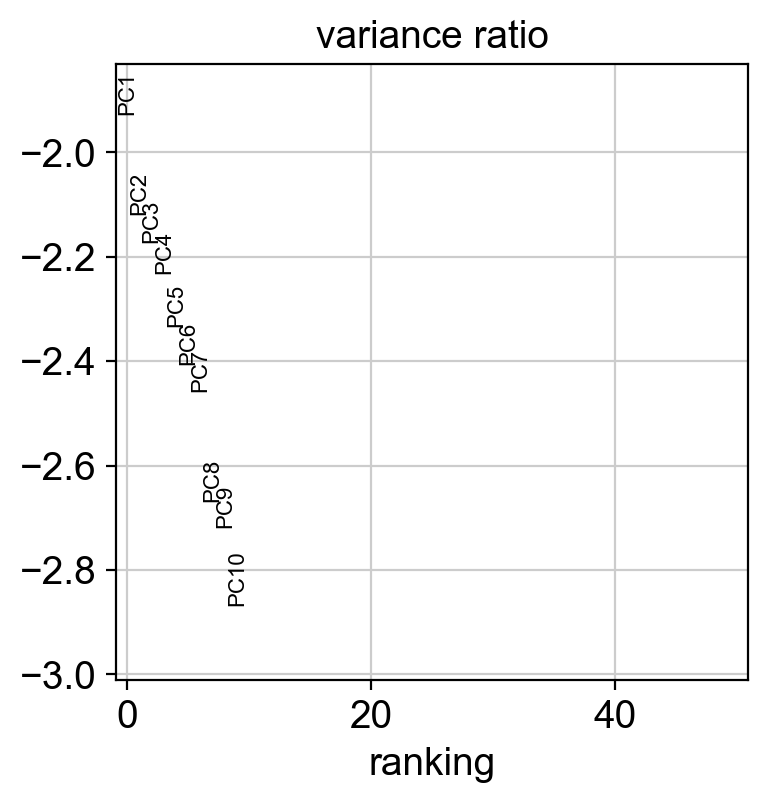

<Figure size 400x400 with 0 Axes>

In [21]:
print("=== Dimensionality Reduction ===")

# Regress out unwanted variation
sc.pp.regress_out(adata, ['total_counts', 'pct_counts_mt'])
print("✓ Regressed out total counts and MT percentage")

# Scale data
sc.pp.scale(adata, max_value=10)
print("✓ Scaled data")

# PCA
sc.tl.pca(adata, svd_solver='arpack')
print("✓ Computed PCA")

# Plot PCA variance ratio
sc.pl.pca_variance_ratio(adata, log=True, n_pcs=50)
plt.tight_layout()
plt.show()

In [22]:
print("=== Building Neighbor Graph ===")

# Compute neighborhood graph
sc.pp.neighbors(adata, n_neighbors=10, n_pcs=40)
print("✓ Computed neighbor graph")

# Compute UMAP embedding
sc.tl.umap(adata)
print("✓ Computed UMAP embedding")

=== Building Neighbor Graph ===
computing neighbors
    using data matrix X directly
    using data matrix X directly


/Users/reedbryan/anaconda3/envs/af/lib/python3.9/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


    finished: added to `.uns['neighbors']`
    `.obsp['distances']`, distances for each pair of neighbors
    `.obsp['connectivities']`, weighted adjacency matrix (0:00:18)
✓ Computed neighbor graph
computing UMAP
✓ Computed neighbor graph
computing UMAP
    finished: added
    'X_umap', UMAP coordinates (adata.obsm)
    'umap', UMAP parameters (adata.uns) (0:00:01)
✓ Computed UMAP embedding
    finished: added
    'X_umap', UMAP coordinates (adata.obsm)
    'umap', UMAP parameters (adata.uns) (0:00:01)
✓ Computed UMAP embedding


In [23]:
print("=== Leiden Clustering ===")

# Run Leiden clustering
sc.tl.leiden(adata, resolution=0.5)
print("✓ Performed Leiden clustering")

# Count cells per cluster
cluster_counts = adata.obs['leiden'].value_counts().sort_index()
print(f"\nClusters found: {len(cluster_counts)}")
print("\nCells per cluster:")
for cluster, count in cluster_counts.items():
    print(f"  Cluster {cluster}: {count} cells")

=== Leiden Clustering ===
running Leiden clustering
    finished: found 6 clusters and added
    'leiden', the cluster labels (adata.obs, categorical) (0:00:00)
✓ Performed Leiden clustering

Clusters found: 6

Cells per cluster:
  Cluster 0: 31 cells
  Cluster 1: 20 cells
  Cluster 2: 19 cells
  Cluster 3: 17 cells
  Cluster 4: 16 cells
  Cluster 5: 15 cells
    finished: found 6 clusters and added
    'leiden', the cluster labels (adata.obs, categorical) (0:00:00)
✓ Performed Leiden clustering

Clusters found: 6

Cells per cluster:
  Cluster 0: 31 cells
  Cluster 1: 20 cells
  Cluster 2: 19 cells
  Cluster 3: 17 cells
  Cluster 4: 16 cells
  Cluster 5: 15 cells


/var/folders/4z/bllxltqd2nvgxqlywd1mjbkw0000gn/T/ipykernel_53798/979133186.py:4: FutureWarning: In the future, the default backend for leiden will be igraph instead of leidenalg.

 To achieve the future defaults please pass: flavor="igraph" and n_iterations=2.  directed must also be False to work with igraph's implementation.
  sc.tl.leiden(adata, resolution=0.5)


=== Visualization ===

✓ Saved clustering plot to leiden_clustering_umap.png

✓ Saved clustering plot to leiden_clustering_umap.png


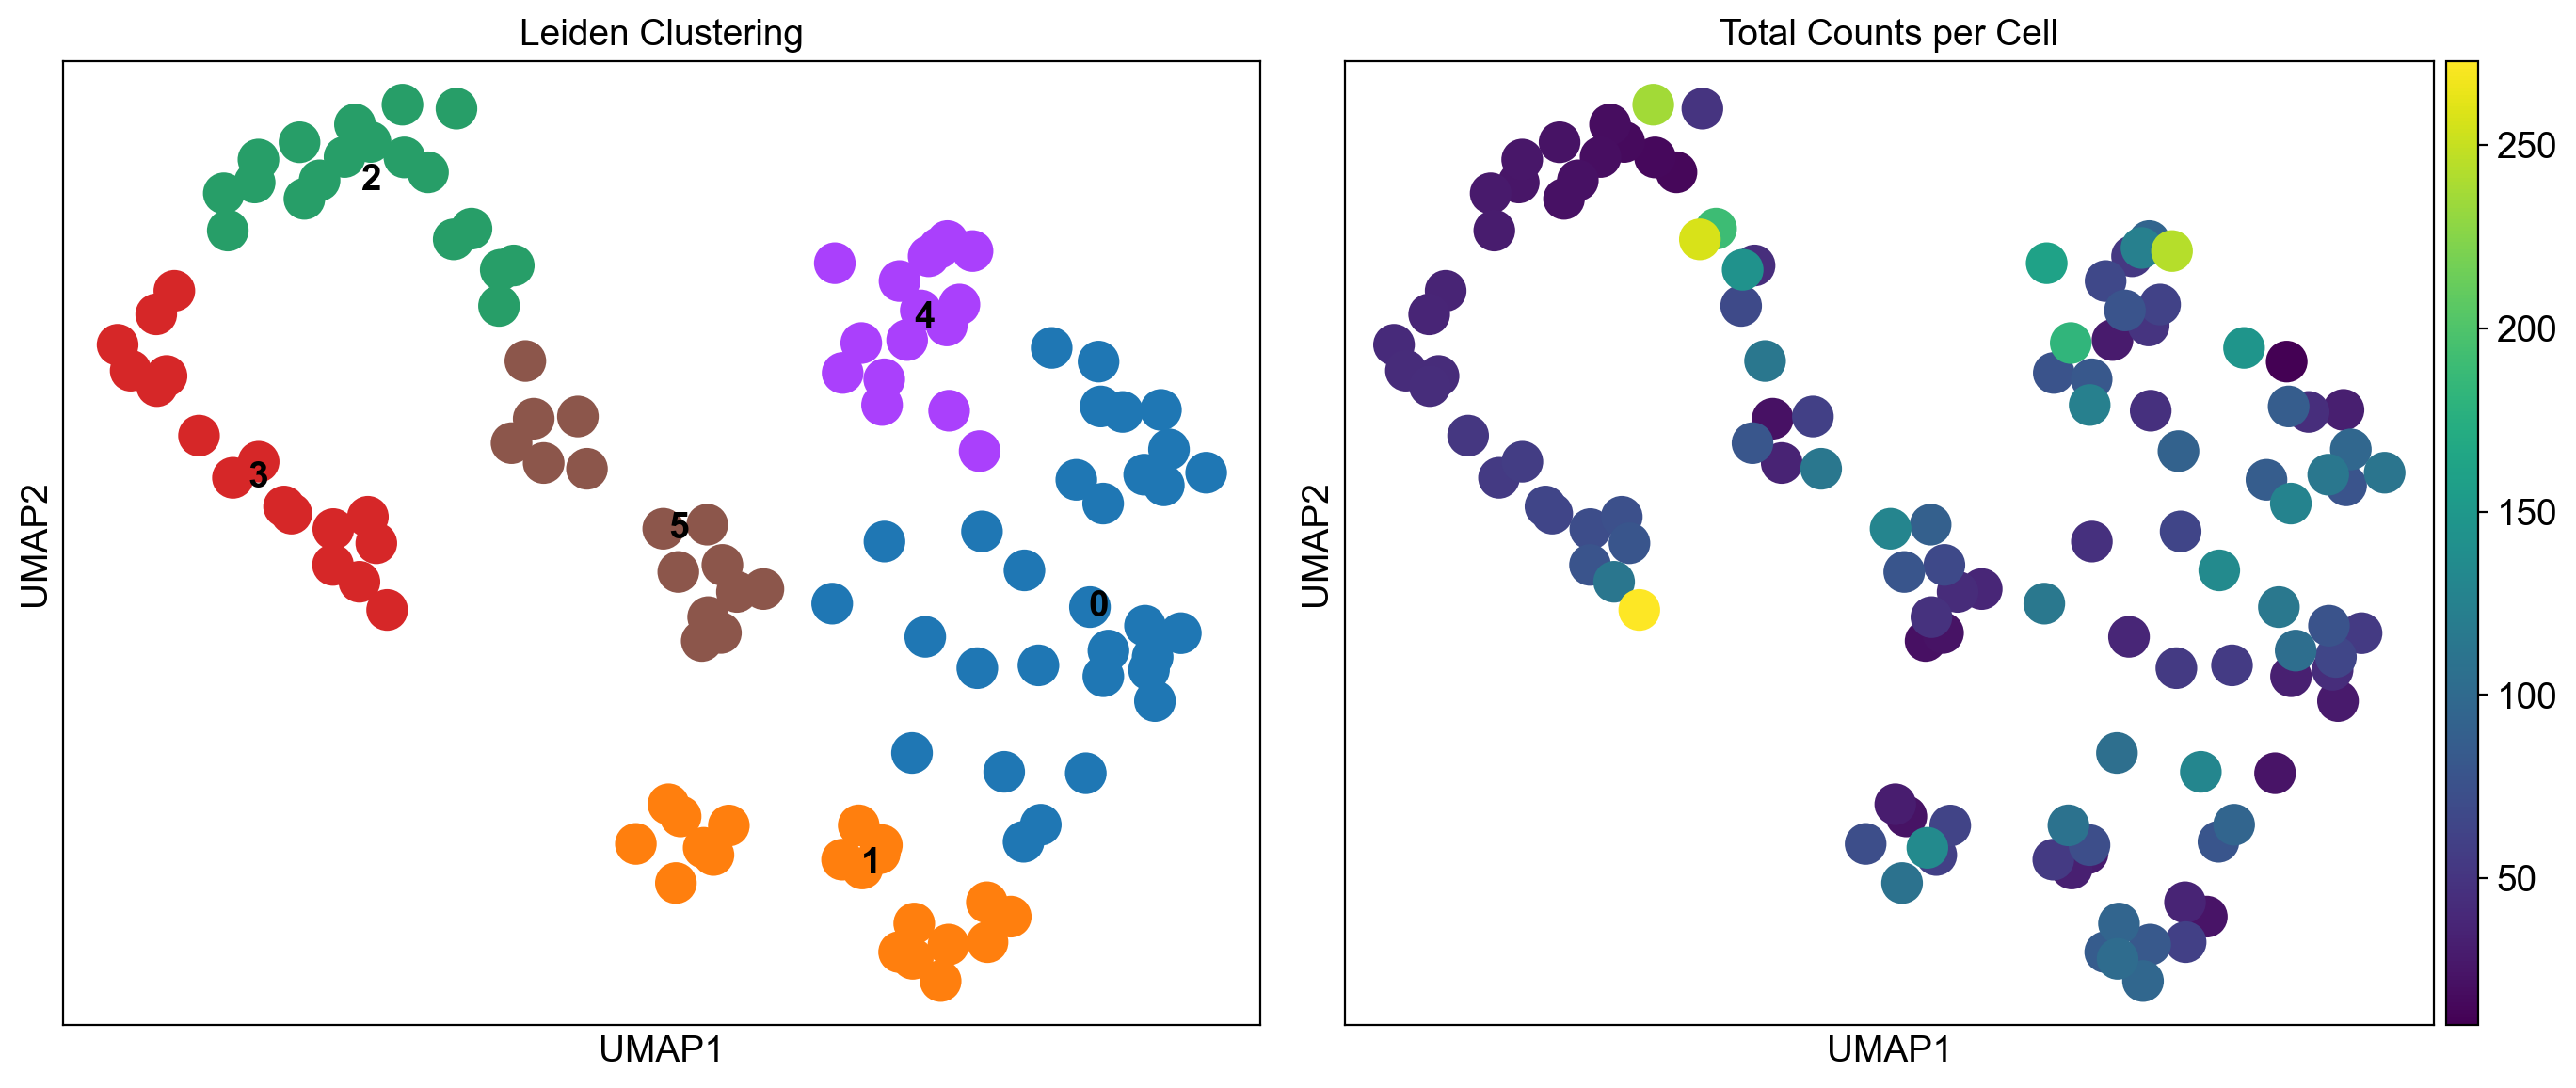

✓ Saved detailed clustering plot to leiden_clustering_detailed.png


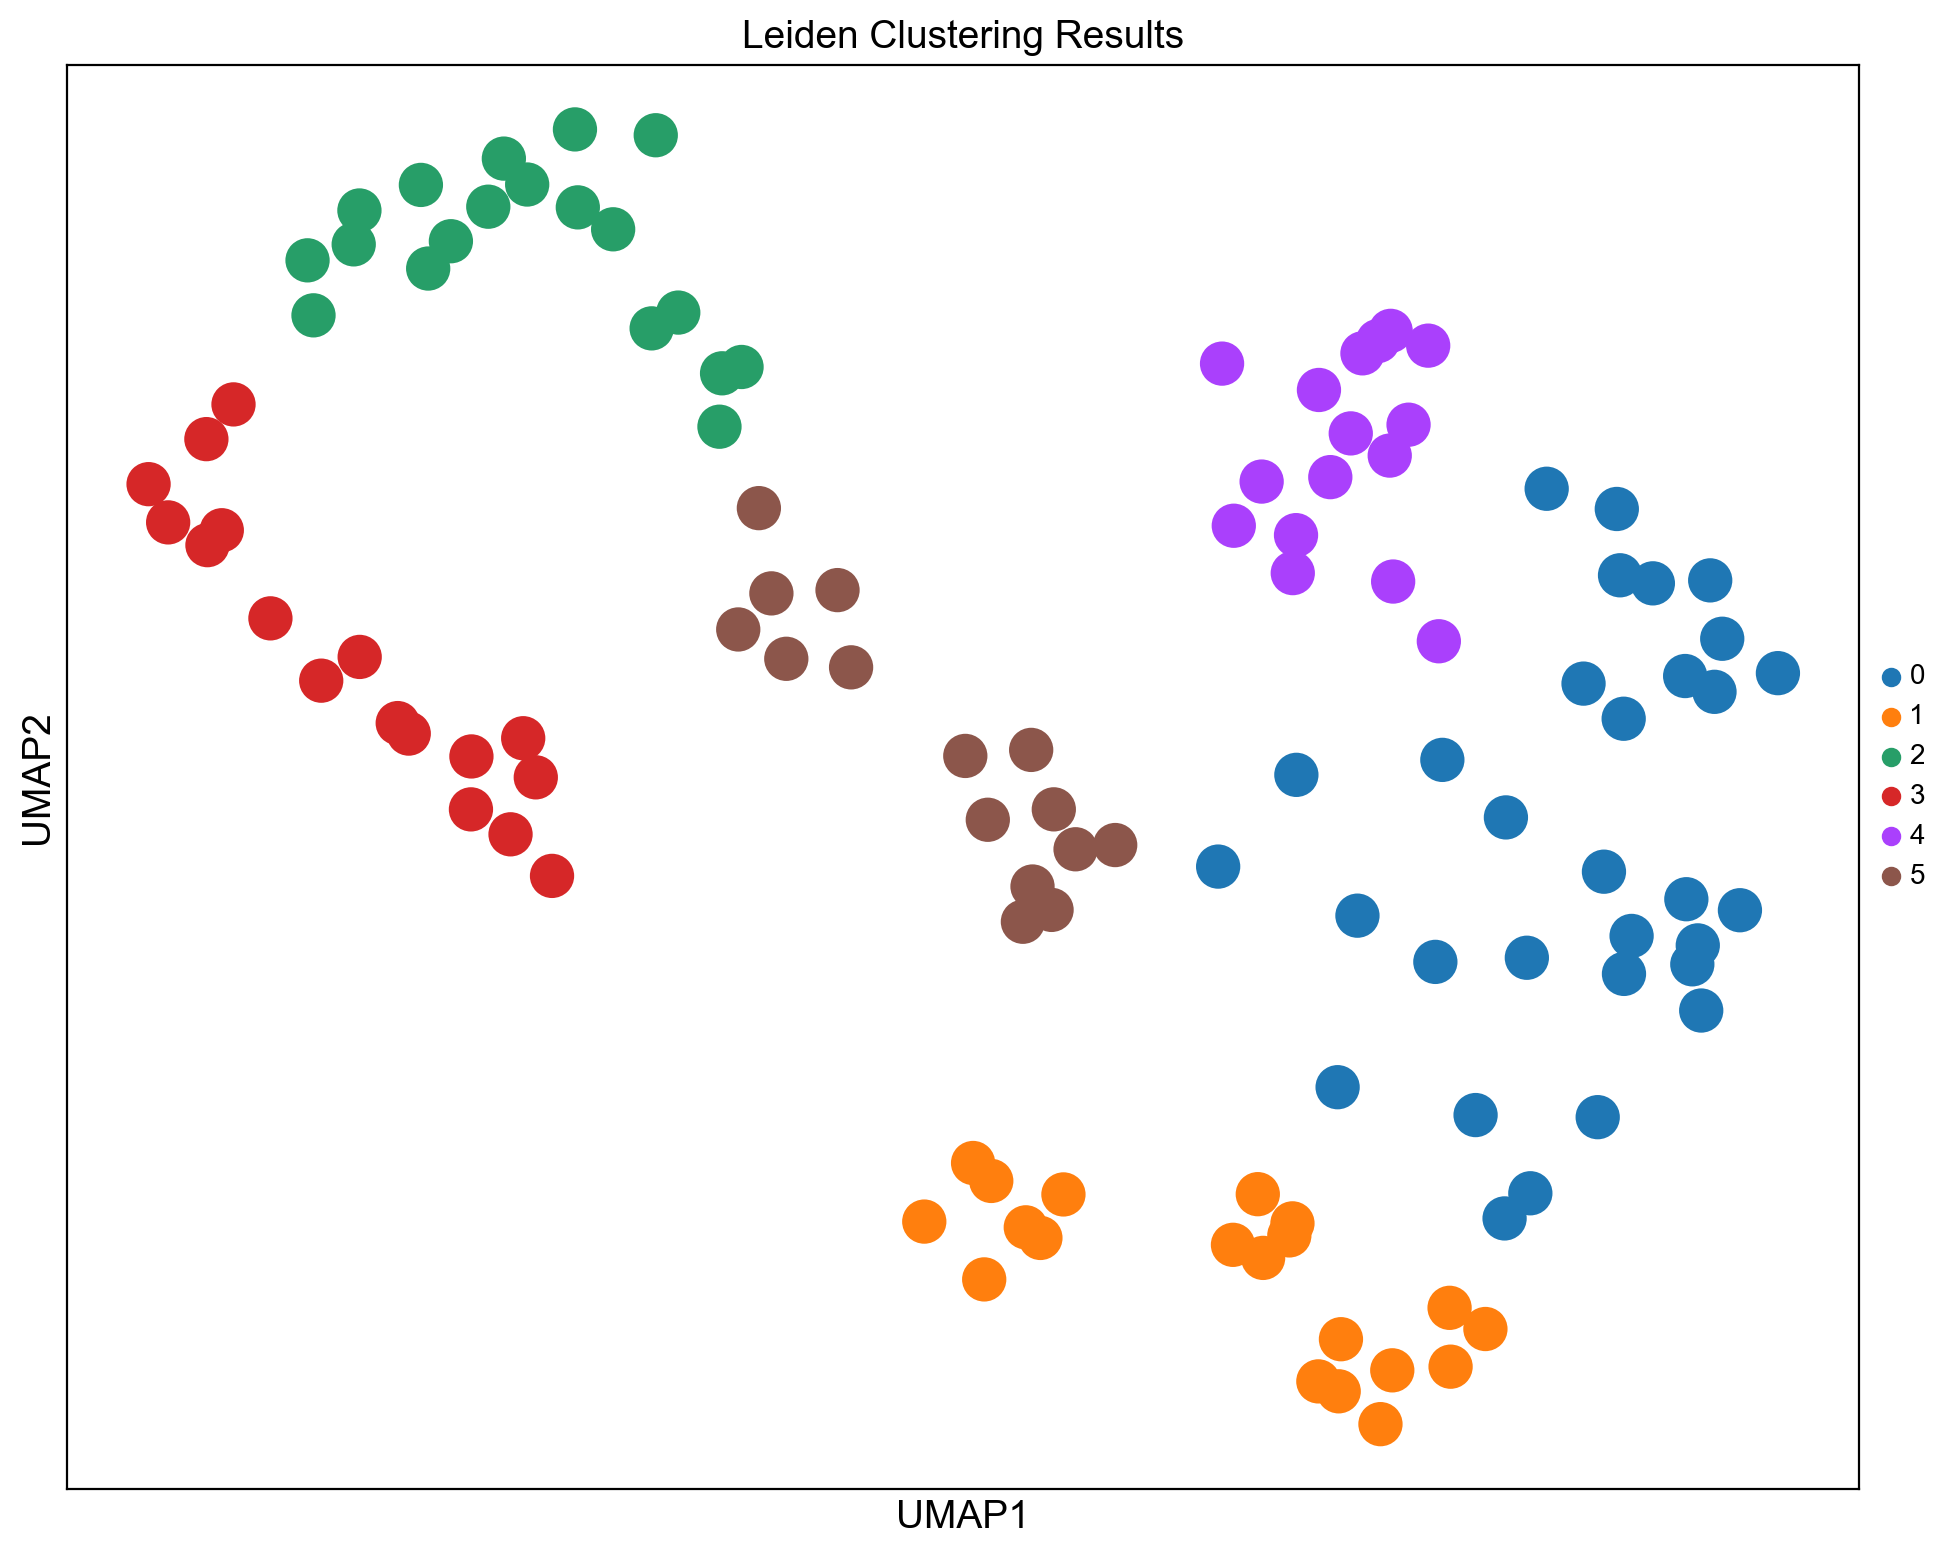

In [24]:
print("=== Visualization ===")

# Create figure with multiple plots
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Plot 1: UMAP colored by Leiden clusters
sc.pl.umap(adata, color='leiden', ax=axes[0], show=False, 
           title='Leiden Clustering', legend_loc='on data')

# Plot 2: UMAP colored by total counts (QC metric)
sc.pl.umap(adata, color='total_counts', ax=axes[1], show=False,
           title='Total Counts per Cell', cmap='viridis')

plt.tight_layout()
plt.savefig('leiden_clustering_umap.png', dpi=300, bbox_inches='tight')
print("\n✓ Saved clustering plot to leiden_clustering_umap.png")
plt.show()

# Additional detailed UMAP plot
fig, ax = plt.subplots(figsize=(10, 8))
sc.pl.umap(adata, color='leiden', ax=ax, show=False,
           title='Leiden Clustering Results', 
           legend_fontsize=10, legend_fontoutline=2)
plt.tight_layout()
plt.savefig('leiden_clustering_detailed.png', dpi=300, bbox_inches='tight')
print("✓ Saved detailed clustering plot to leiden_clustering_detailed.png")
plt.show()

In [25]:
print("=== Clustering Summary ===\n")

print(f"Total cells analyzed: {adata.n_obs}")
print(f"Number of clusters: {len(adata.obs['leiden'].unique())}")
print(f"Genes used for clustering: {adata.n_vars} (highly variable)")

print("\n" + "="*60)
print("CLUSTER STATISTICS")
print("="*60)

cluster_stats = pd.DataFrame({
    'n_cells': adata.obs.groupby('leiden').size(),
    'mean_genes': adata.obs.groupby('leiden')['n_genes_by_counts'].mean(),
    'mean_counts': adata.obs.groupby('leiden')['total_counts'].mean()
})

print(cluster_stats.to_string())

print("\n✓ Leiden clustering completed successfully!")

=== Clustering Summary ===

Total cells analyzed: 118
Number of clusters: 6
Genes used for clustering: 11 (highly variable)

CLUSTER STATISTICS
        n_cells  mean_genes  mean_counts
leiden                                  
0            31   26.935484    77.387097
1            20   23.650000    68.650000
2            19   20.789474    65.947368
3            17   23.000000    71.823529
4            16   28.937500    97.875000
5            15   23.600000    64.266667

✓ Leiden clustering completed successfully!


/var/folders/4z/bllxltqd2nvgxqlywd1mjbkw0000gn/T/ipykernel_53798/3424506123.py:12: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  'n_cells': adata.obs.groupby('leiden').size(),
/var/folders/4z/bllxltqd2nvgxqlywd1mjbkw0000gn/T/ipykernel_53798/3424506123.py:13: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  'mean_genes': adata.obs.groupby('leiden')['n_genes_by_counts'].mean(),
/var/folders/4z/bllxltqd2nvgxqlywd1mjbkw0000gn/T/ipykernel_53798/3424506123.py:14: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current b